In [1]:
import numpy as np
import matplotlib.pyplot as plt
from meer21cm import MockSimulation
from meer21cm.util import create_wcs_with_range,pca_clean
from meer21cm.plot import plot_map
from meer21cm.fg import ForegroundSimulation
### Define beam for mocks:
from meer21cm.telescope import dish_beam_sigma
from meer21cm.telescope import weighted_convolution
from meer21cm.telescope import isotropic_beam_profile
from meer21cm.telescope import gaussian_beam

### Mock specifications:
ra_range = [125,175]
dec_range = [-10,5]
wcs, num_pix_x, num_pix_y = create_wcs_with_range(
    ra_range,
    dec_range,
    resol=[0.5, 0.5],
    buffer=[1.2, 1.2])

nu = np.linspace(800,900,80) * 1e6 # [Hz]

mock = MockSimulation(
    seed=1234,
    nu=nu,
    wproj=wcs,
    num_pix_x=num_pix_x,
    num_pix_y=num_pix_y,
    omega_hi=5e-4,
    tracer_bias_1=1.5,
    ra_range=ra_range,
    dec_range=dec_range,
    mean_amp_1='average_hi_temp',
    density='lognormal',
    downres_factor_radial = 1/2,
    downres_factor_transverse = 1/2,
)

d_dish = 13.5
sigma_beam_ch = dish_beam_sigma(d_dish, nu)
beam = np.zeros((num_pix_x,num_pix_y,len(nu)))
for i in range(len(nu)):
    beam[:,:,i] = isotropic_beam_profile(num_pix_x,num_pix_y,wcs, gaussian_beam(sigma_beam_ch[i]) )

In [2]:
# simulate HI
mock.data = mock.propagate_mock_field_to_data(mock.mock_tracer_field_1)
HI_map = mock.data

# simulate foreground
fg = ForegroundSimulation(
    hp_nside=256,
    wproj=mock.wproj,
    num_pix_x=mock.num_pix_x,
    num_pix_y=mock.num_pix_y,
    backend="pysm",
    pysm_preset_strings=["d1", "s1", "a1", "c1"],
    coord_system="C",
)
fg_map = fg.fg_wcs_cube(mock.nu)

# convolve map with beam
w = np.ones(np.shape(HI_map))
HI_map,w = weighted_convolution(HI_map,beam,w)
fg_map,w = weighted_convolution(fg_map,beam,w)

In [3]:
# add noise (just for illustration)
sigma_N = 4e-5
noise  = np.random.normal(0,sigma_N,np.shape(fg_map))
# PCA cleaning
obs_map = fg_map + noise + HI_map
N_fg = 5
clean_map = pca_clean(obs_map,N_fg,weights=mock.W_HI,mean_center=True, return_A=False)

fg_map[mock.W_HI==0] = np.nan
clean_map[mock.W_HI==0] = np.nan
HI_map[mock.W_HI==0] = np.nan

/tmp/ipykernel_2848026/1455883099.py:15: RuntimeWarning: Mean of empty slice
  plt.imshow(np.nanmean(maps[i][:,:,int(len(nu)/2):int(len(nu)/2+10)],2).T)


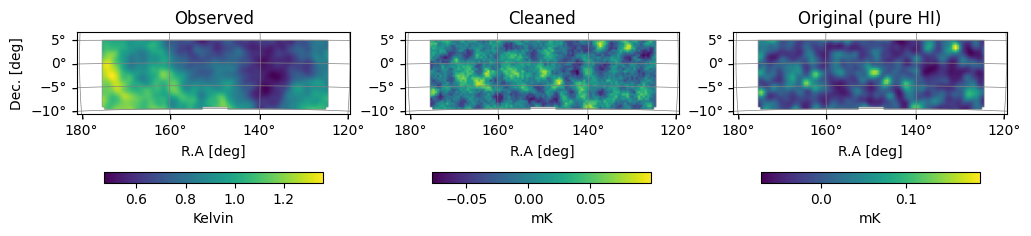

In [4]:
maps = [fg_map,1e3*clean_map,1e3*HI_map]

titles = ['Observed','Cleaned','Original (pure HI)']
cbarlabels = ['Kelvin','mK','mK']
plt.figure(figsize=(12,5))
for i in range(3):
    plt.subplot(1, 3, i+1, projection=mock.wproj)
    ax = plt.gca()
    lon = ax.coords[0]
    lat = ax.coords[1]
    lon.set_major_formatter('d')
    lon.set_ticks_position('b')
    lat.set_ticks_position('l')
    plt.grid(True, color='grey', ls='solid',lw=0.5)
    plt.imshow(np.nanmean(maps[i][:,:,int(len(nu)/2):int(len(nu)/2+10)],2).T)
    plt.colorbar(shrink=0.8,orientation='horizontal',label=cbarlabels[i])
    plt.xlabel('R.A [deg]')
    if i==0: plt.ylabel('Dec. [deg]')
    else: plt.ylabel('')
    plt.gca().invert_xaxis()
    plt.title(titles[i])
plt.savefig('plots/maps_Fig1.pdf',bbox_inches='tight')